# Lab 6: Visualize Attention Heatmaps in Seq2Seq

This notebook builds a small LSTM Sequence-to-Sequence model with attention and visualizes the attention scores as a heatmap.

The task is to reverse a sequence of digits.

Example:

`Input: 3 8 1 6`

`Output: 6 1 8 3`

In [1]:
# ============================================================
# BLOCK 1: Import required libraries
# ============================================================

import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf

from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, Embedding, LSTM, Dense, AdditiveAttention, Concatenate

print("TensorFlow version:", tf.__version__)

TensorFlow version: 2.20.0


In [2]:
# ============================================================
# BLOCK 2: Create toy Seq2Seq dataset
# ============================================================

PAD = 0
START = 1
END = 2

# Digits 0-9 are represented by token IDs 3-12.
DIGIT_OFFSET = 3
VOCAB_SIZE = 13
MAX_SEQ_LEN = 8

def generate_seq2seq_data(num_samples=12000):
    encoder_inputs = []
    decoder_inputs = []
    decoder_outputs = []

    for _ in range(num_samples):
        length = np.random.randint(3, MAX_SEQ_LEN + 1)

        digits = np.random.randint(0, 10, size=length)
        source = digits + DIGIT_OFFSET
        target = source[::-1]

        enc = np.zeros(MAX_SEQ_LEN, dtype="int32")
        dec_in = np.zeros(MAX_SEQ_LEN + 1, dtype="int32")
        dec_out = np.zeros(MAX_SEQ_LEN + 1, dtype="int32")

        enc[:length] = source

        # Decoder receives START first, then previous target tokens.
        dec_in[0] = START
        dec_in[1:length + 1] = target

        # Decoder output is the reversed sequence followed by END.
        dec_out[:length] = target
        dec_out[length] = END

        encoder_inputs.append(enc)
        decoder_inputs.append(dec_in)
        decoder_outputs.append(dec_out)

    return np.array(encoder_inputs), np.array(decoder_inputs), np.array(decoder_outputs)

encoder_input_data, decoder_input_data, decoder_output_data = generate_seq2seq_data()

print("Encoder input shape:", encoder_input_data.shape)
print("Decoder input shape:", decoder_input_data.shape)
print("Decoder output shape:", decoder_output_data.shape)

Encoder input shape: (12000, 8)
Decoder input shape: (12000, 9)
Decoder output shape: (12000, 9)


In [3]:
# ============================================================
# BLOCK 3: Helper function to display token IDs as readable text
# ============================================================

def token_to_text(tokens):
    text_tokens = []

    for token in tokens:
        token = int(token)

        if token == PAD:
            continue
        elif token == START:
            text_tokens.append("<start>")
        elif token == END:
            text_tokens.append("<end>")
        else:
            text_tokens.append(str(token - DIGIT_OFFSET))

    return text_tokens

In [4]:
# ============================================================
# BLOCK 4: Build Seq2Seq model with additive attention
# ============================================================

EMBED_DIM = 64
LATENT_DIM = 128

# Encoder input layer
encoder_inputs = Input(shape=(MAX_SEQ_LEN,), name="encoder_inputs")

# Encoder embedding layer
encoder_embedding = Embedding(VOCAB_SIZE, EMBED_DIM, mask_zero=True, name="encoder_embedding")
encoder_embedded = encoder_embedding(encoder_inputs)

# Encoder LSTM returns all time-step outputs because attention needs them.
encoder_lstm = LSTM(
    LATENT_DIM,
    return_sequences=True,
    return_state=True,
    name="encoder_lstm"
)

encoder_outputs, state_h, state_c = encoder_lstm(encoder_embedded)

# Decoder input layer
decoder_inputs = Input(shape=(MAX_SEQ_LEN + 1,), name="decoder_inputs")

# Decoder embedding layer
decoder_embedding = Embedding(VOCAB_SIZE, EMBED_DIM, mask_zero=True, name="decoder_embedding")
decoder_embedded = decoder_embedding(decoder_inputs)

# Decoder LSTM uses encoder final states as initial states.
decoder_lstm = LSTM(
    LATENT_DIM,
    return_sequences=True,
    return_state=True,
    name="decoder_lstm"
)

decoder_outputs, _, _ = decoder_lstm(
    decoder_embedded,
    initial_state=[state_h, state_c]
)

# Additive attention compares decoder states with encoder outputs.
attention_layer = AdditiveAttention(name="attention_layer")

context_vectors, attention_scores = attention_layer(
    [decoder_outputs, encoder_outputs],
    return_attention_scores=True
)

# Combine decoder output with attention context vector.
combined_outputs = Concatenate(name="concat_context")([decoder_outputs, context_vectors])

# Final token prediction layer
output_layer = Dense(VOCAB_SIZE, activation="softmax", name="output_layer")
final_outputs = output_layer(combined_outputs)

# Training model
seq2seq_attention_model = Model(
    [encoder_inputs, decoder_inputs],
    final_outputs
)

# Separate model that also returns attention scores for heatmap visualization.
attention_visualization_model = Model(
    [encoder_inputs, decoder_inputs],
    [final_outputs, attention_scores]
)

seq2seq_attention_model.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

seq2seq_attention_model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ encoder_inputs      │ (None, 8)         │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ decoder_inputs      │ (None, 9)         │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ encoder_embedding   │ (None, 8, 64)     │        832 │ encoder_inputs[0… │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ not_equal           │ (None, 8)         │          0 │ encoder_inputs[0… │
│ (NotEqual)          │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ decoder_embedding   │ (None, 9, 64)     │        832 │ decoder_inputs[0… │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ encoder_lstm (LSTM) │ [(None, 8, 128),  │     98,816 │ encoder_embeddin… │
│                     │ (None, 128),      │            │ not_equal[0][0]   │
│                     │ (None, 128)]      │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ decoder_lstm (LSTM) │ [(None, 9, 128),  │     98,816 │ decoder_embeddin… │
│                     │ (None, 128),      │            │ encoder_lstm[0][… │
│                     │ (None, 128)]      │            │ encoder_lstm[0][… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ attention_layer     │ [(None, 9, 128),  │        128 │ decoder_lstm[0][… │
│ (AdditiveAttention) │ (None, 9, 8)]     │            │ encoder_lstm[0][… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concat_context      │ (None, 9, 256)    │          0 │ decoder_lstm[0][… │
│ (Concatenate)       │                   │            │ attention_layer[… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ output_layer        │ (None, 9, 13)     │      3,341 │ concat_context[0… │
│ (Dense)             │                   │            │                   │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 202,765 (792.05 KB)

 Trainable params: 202,765 (792.05 KB)

 Non-trainable params: 0 (0.00 B)

In [5]:
# ============================================================
# BLOCK 5: Train the Seq2Seq attention model
# ============================================================

history = seq2seq_attention_model.fit(
    [encoder_input_data, decoder_input_data],
    decoder_output_data,
    epochs=10,
    batch_size=64,
    validation_split=0.2
)

Epoch 1/10
150/150 ━━━━━━━━━━━━━━━━━━━━ 9s 21ms/step - accuracy: 0.4019 - loss: 1.6765 - val_accuracy: 0.6026 - val_loss: 1.0808
Epoch 2/10
150/150 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - accuracy: 0.8335 - loss: 0.5473 - val_accuracy: 0.9424 - val_loss: 0.2525
Epoch 3/10
150/150 ━━━━━━━━━━━━━━━━━━━━ 3s 10ms/step - accuracy: 0.9655 - loss: 0.1698 - val_accuracy: 0.9764 - val_loss: 0.1203
Epoch 4/10
150/150 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - accuracy: 0.9857 - loss: 0.0880 - val_accuracy: 0.9873 - val_loss: 0.0728
Epoch 5/10
150/150 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - accuracy: 0.9895 - loss: 0.0612 - val_accuracy: 0.9902 - val_loss: 0.0528
Epoch 6/10
150/150 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - accuracy: 0.9934 - loss: 0.0423 - val_accuracy: 0.9950 - val_loss: 0.0348
Epoch 7/10
150/150 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - accuracy: 0.9969 - loss: 0.0274 - val_accuracy: 0.9953 - val_loss: 0.0292
Epoch 8/10
150/150 ━━━━━━━━━━━━━━━━━━━━ 2s 14ms/step - accuracy: 0.9964 - loss: 0.0261 - val_accuracy

In [6]:
# ============================================================
# BLOCK 6: Test prediction from the trained model
# ============================================================

def predict_sequence(sample_index):
    enc = encoder_input_data[sample_index:sample_index + 1]
    dec = decoder_input_data[sample_index:sample_index + 1]

    predictions = seq2seq_attention_model.predict([enc, dec], verbose=0)
    predicted_tokens = np.argmax(predictions[0], axis=-1)

    print("Input sequence:   ", token_to_text(enc[0]))
    print("Expected output:  ", token_to_text(decoder_output_data[sample_index]))
    print("Predicted output: ", token_to_text(predicted_tokens))

predict_sequence(0)
predict_sequence(1)
predict_sequence(2)

Input sequence:    ['7', '4', '1']
Expected output:   ['1', '4', '7', '<end>']
Predicted output:  ['1', '4', '7', '<end>', '<end>', '<end>', '<end>', '<end>', '<end>']
Input sequence:    ['2', '6', '3', '9', '7']
Expected output:   ['7', '9', '3', '6', '2', '<end>']
Predicted output:  ['7', '9', '3', '6', '2', '<end>', '<end>', '<end>', '<end>']
Input sequence:    ['7', '7', '9', '8', '1', '8']
Expected output:   ['8', '1', '8', '9', '7', '7', '<end>']
Predicted output:  ['8', '1', '8', '9', '7', '7', '<end>', '<end>', '<end>']


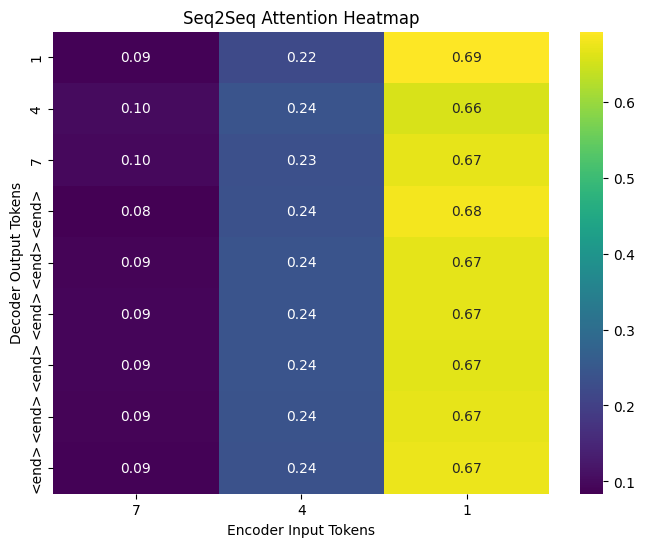

Input sequence:    ['7', '4', '1']
Predicted output:  ['1', '4', '7', '<end>', '<end>', '<end>', '<end>', '<end>', '<end>']


In [7]:
# ============================================================
# BLOCK 7: Visualize attention heatmap
# ============================================================

def plot_attention_heatmap(sample_index):
    enc = encoder_input_data[sample_index:sample_index + 1]
    dec = decoder_input_data[sample_index:sample_index + 1]

    predictions, attention = attention_visualization_model.predict([enc, dec], verbose=0)
    predicted_tokens = np.argmax(predictions[0], axis=-1)

    input_tokens = token_to_text(enc[0])
    output_tokens = token_to_text(predicted_tokens)

    input_len = len(input_tokens)
    output_len = len(output_tokens)

    # attention shape: batch_size x decoder_time_steps x encoder_time_steps
    attention_matrix = attention[0][:output_len, :input_len]

    plt.figure(figsize=(8, 6))
    sns.heatmap(
        attention_matrix,
        xticklabels=input_tokens,
        yticklabels=output_tokens,
        cmap="viridis",
        annot=True,
        fmt=".2f"
    )

    plt.xlabel("Encoder Input Tokens")
    plt.ylabel("Decoder Output Tokens")
    plt.title("Seq2Seq Attention Heatmap")
    plt.show()

    print("Input sequence:   ", input_tokens)
    print("Predicted output: ", output_tokens)

plot_attention_heatmap(0)

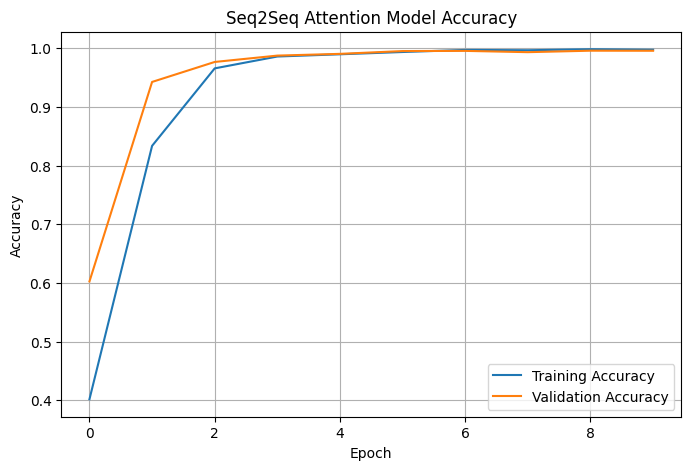

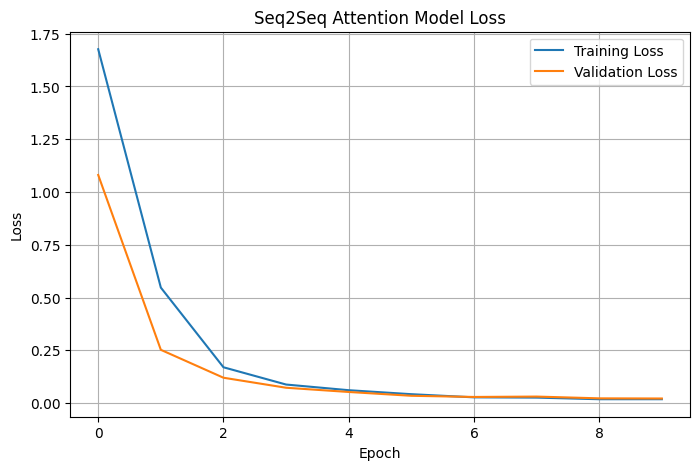

In [8]:
# ============================================================
# BLOCK 8: Plot training accuracy and loss
# ============================================================

plt.figure(figsize=(8, 5))
plt.plot(history.history["accuracy"], label="Training Accuracy")
plt.plot(history.history["val_accuracy"], label="Validation Accuracy")
plt.title("Seq2Seq Attention Model Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.grid(True)
plt.show()

plt.figure(figsize=(8, 5))
plt.plot(history.history["loss"], label="Training Loss")
plt.plot(history.history["val_loss"], label="Validation Loss")
plt.title("Seq2Seq Attention Model Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.grid(True)
plt.show()

## Lab 6 Conclusion

The attention heatmap shows which encoder input tokens the decoder focuses on while generating each output token. Brighter values mean stronger attention. Attention improves Seq2Seq models because the decoder can refer directly to relevant encoder time steps instead of relying only on the final encoder state.